## Datenintegration BTC + XAU

In [9]:
import pandas as pd

# Pfade zu den bereinigten CSV-Dateien
df_btc = pd.read_csv('../dataset/output/BTCUSD_1d_analysis_clean.csv', parse_dates=['date_btc'])
df_xau = pd.read_csv('../dataset/output/XAUUSD_1d_analysis_clean.csv', parse_dates=['date_xau'])

# Schritt 1: Spalten für Join vereinheitlichen
df_btc = df_btc.rename(columns={'date_btc': 'date'})
df_xau = df_xau.rename(columns={'date_xau': 'date'})

# Schritt 2: Mergen der Datensätze anhand des Datums
merged_df = pd.merge(df_btc, df_xau, on='date', how='inner')

# Schritt 3: Sortieren und Speichern
merged_df = merged_df.sort_values('date').reset_index(drop=True)
merged_df.to_csv('../dataset/output/final_merged_dataset.csv', index=False)
print(merged_df.head())

                       date  open_btc  high_btc  low_btc  close_btc  \
0 2014-11-28 00:00:00+00:00    363.59    381.34   360.57     376.28   
1 2014-12-01 00:00:00+00:00    376.40    382.31   373.03     378.39   
2 2014-12-02 00:00:00+00:00    378.39    382.86   375.23     379.25   
3 2014-12-03 00:00:00+00:00    379.25    383.00   374.23     376.67   
4 2014-12-04 00:00:00+00:00    376.67    378.99   360.01     365.20   

   volume_usd_btc open_xau high_xau  low_xau close_xau  volume_xau  
0         8617.15  1188.92  1190.64  1165.06   1165.88       68176  
1         6660.56  1158.49   1220.8  1141.74    1210.8      138509  
2         6832.53  1211.04  1212.51  1191.85    1198.5      104108  
3         7908.29  1197.07  1214.96  1194.22   1209.47       66218  
4         8865.09  1208.55  1213.28  1201.17   1205.45       64221  


## Berechnungen

In [23]:
import pandas as pd
import numpy as np
from scipy import stats

# Datensatz laden
df = pd.read_csv('../dataset/output/final_merged_dataset.csv', parse_dates=['date'])

# Bootstrap-Funktion
def bootstrap_ci(data, func, n=1000, ci=0.95):
    boot_samples = [func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n)]
    lower = np.percentile(boot_samples, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_samples, (1 + ci) / 2 * 100)
    return (lower, upper)

# Statistiken mit Konfidenzintervallen berechnen
def beschreibung(name, daten):
    daten = daten.dropna().values
    print(f"\n{name}")

    mean = np.mean(daten)
    median = np.median(daten)
    std = np.std(daten, ddof=1)
    iqr = np.percentile(daten, 75) - np.percentile(daten, 25)

    print(f"Mittelwert: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Standardabweichung: {std:.2f}")
    print(f"IQR: {iqr:.2f}")

    # Konfidenzintervalle
    ci_mean = stats.t.interval(0.95, len(daten)-1, loc=mean, scale=stats.sem(daten))
    ci_median = bootstrap_ci(daten, np.median)
    ci_std = bootstrap_ci(daten, lambda x: np.std(x, ddof=1))
    ci_iqr = bootstrap_ci(daten, lambda x: np.percentile(x, 75) - np.percentile(x, 25))

    print(f"95% CI Mittelwert: ({ci_mean[0]:.2f}, {ci_mean[1]:.2f})")
    print(f"95% CI Median: ({ci_median[0]:.2f}, {ci_median[1]:.2f})")
    print(f"95% CI Standardabw.: ({ci_std[0]:.2f}, {ci_std[1]:.2f})")
    print(f"95% CI IQR: ({ci_iqr[0]:.2f}, {ci_iqr[1]:.2f})")

# Aufruf für BTC und XAU
beschreibung("BTC Schlusskurs (close_btc)", df['close_btc'])
beschreibung("XAU Schlusskurs (close_xau)", df['close_xau'])




BTC Schlusskurs (close_btc)
Mittelwert: 20518.35
Median: 9635.40
Standardabweichung: 23199.40
IQR: 30377.52
95% CI Mittelwert: (19629.27, 21407.43)
95% CI Median: (9280.85, 10203.65)
95% CI Standardabw.: (22400.26, 23972.62)
95% CI IQR: (27731.06, 33647.98)

XAU Schlusskurs (close_xau)
Mittelwert: 1607.55
Median: 1527.12
Standardabweichung: 403.14
IQR: 612.96
95% CI Mittelwert: (1592.11, 1623.00)
95% CI Median: (1492.78, 1595.57)
95% CI Standardabw.: (391.90, 413.98)
95% CI IQR: (598.71, 631.68)


## Preisentwicklung von BTC und XAU

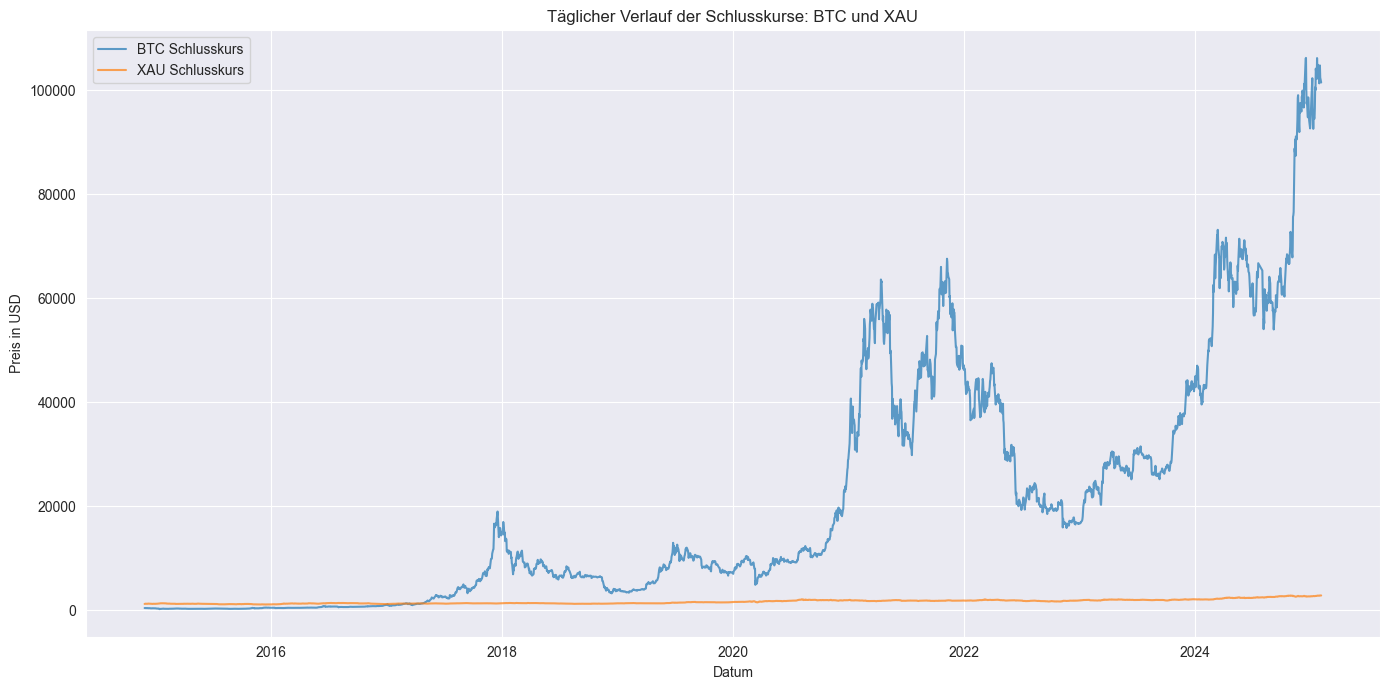

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datensatz laden (aus final_merged_dataset.csv)
df = pd.read_csv('../dataset/output/final_merged_dataset.csv', parse_dates=['date'])

# Tagesdiagramm BTC und XAU Schlusskurse
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close_btc'], label='BTC Schlusskurs', alpha=0.7)
plt.plot(df['date'], df['close_xau'], label='XAU Schlusskurs', alpha=0.7)
plt.title('Täglicher Verlauf der Schlusskurse: BTC und XAU')
plt.xlabel('Datum')
plt.ylabel('Preis in USD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Preisentwicklung von BTC und XAU mit logarithmischer Skala

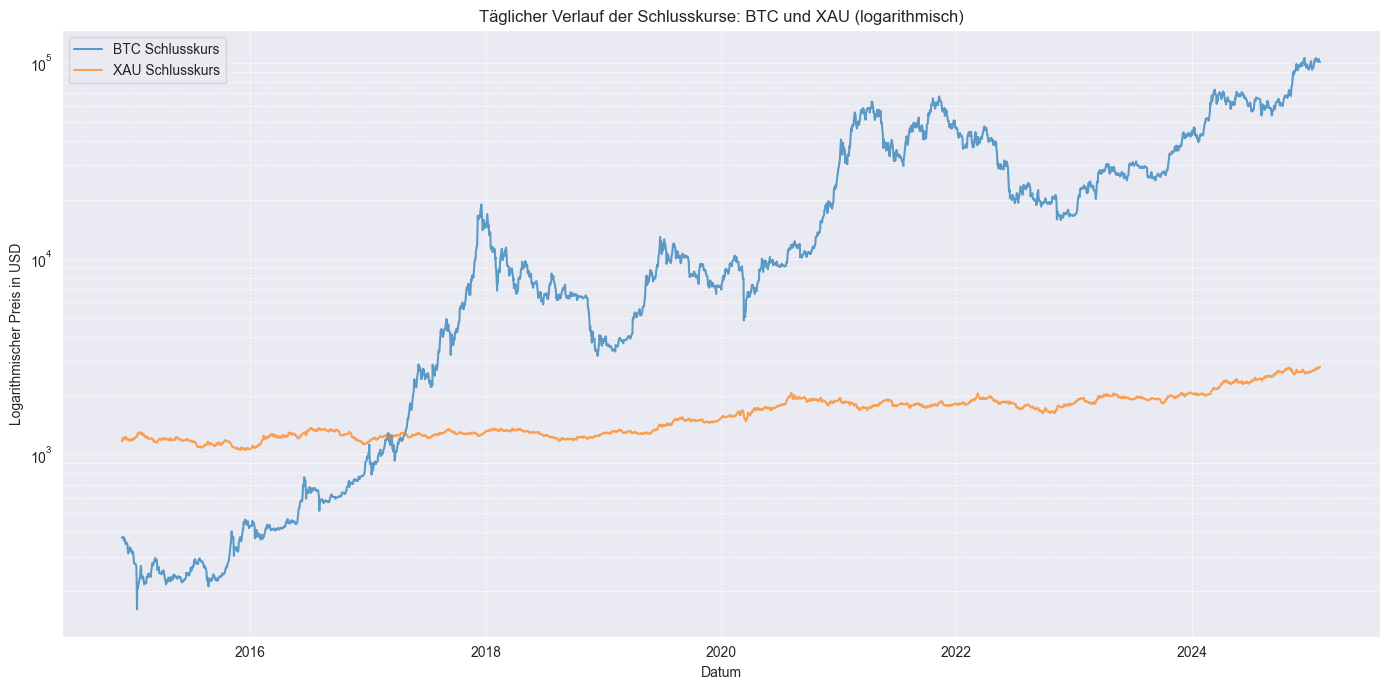

In [10]:
# Plot
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close_btc'], label='BTC Schlusskurs', alpha=0.7)
plt.plot(df['date'], df['close_xau'], label='XAU Schlusskurs', alpha=0.7)

# Logarithmische Y-Achse
plt.yscale('log')

# Diagrammgestaltung
plt.title('Täglicher Verlauf der Schlusskurse: BTC und XAU (logarithmisch)')
plt.xlabel('Datum')
plt.ylabel('Logarithmischer Preis in USD')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


## Korrelation der Schlusskurse

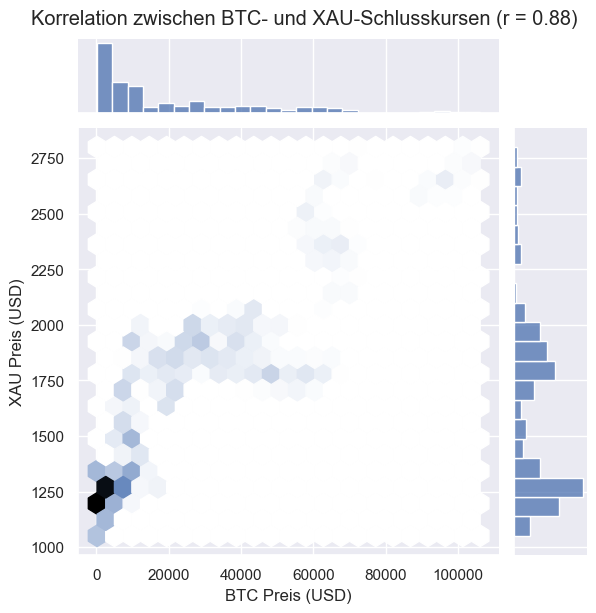

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df['close_btc'].corr(df['close_xau'])

sns.jointplot(x='close_btc', y='close_xau', data=df, kind='hex')
plt.suptitle(f"Korrelation zwischen BTC- und XAU-Schlusskursen (r = {corr:.2f})", y=1.02)
plt.xlabel("BTC Preis (USD)")
plt.ylabel("XAU Preis (USD)")
plt.show()


## Scatterplot

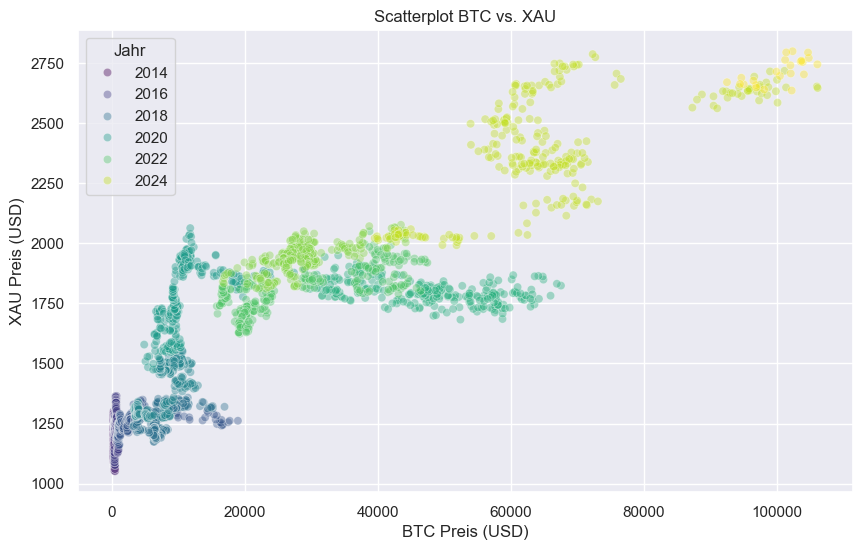

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Jahr extrahieren
df['year'] = df['date'].dt.year

plt.figure(figsize=(10, 6))
sns.scatterplot(x='close_btc', y='close_xau', hue='year', data=df, palette='viridis', alpha=0.4, legend='brief')
plt.title("Scatterplot BTC vs. XAU")
plt.xlabel("BTC Preis (USD)")
plt.ylabel("XAU Preis (USD)")
plt.grid(True)
plt.legend(title='Jahr')
plt.show()


## Boxplot der täglichen Renditen von Bitcoin (BTC) und Gold (XAU)

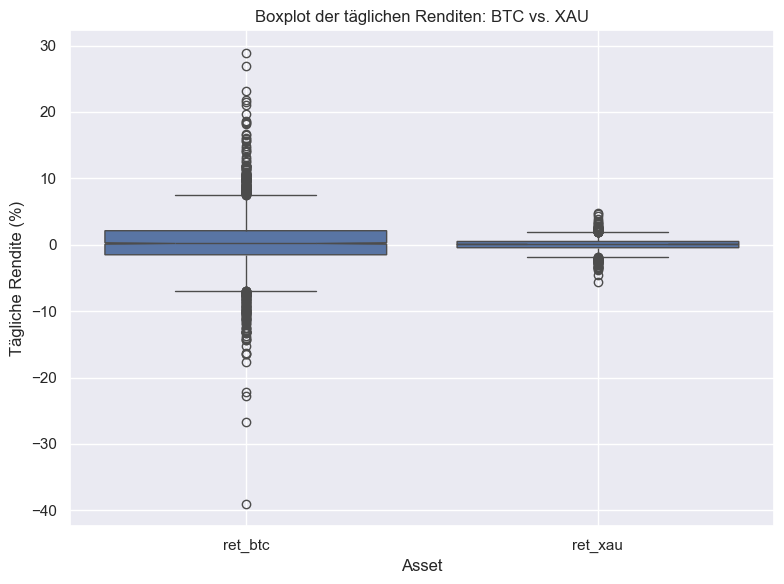

In [19]:
# Tägliche Renditen berechnen (in %)
df['ret_btc'] = df['close_btc'].pct_change() * 100
df['ret_xau'] = df['close_xau'].pct_change() * 100

# Daten vorbereiten (für Seaborn)
returns_df = df[['ret_btc', 'ret_xau']].dropna()
returns_df = returns_df.melt(var_name='Asset', value_name='Tägliche Rendite (%)')

# Boxplot erstellen
plt.figure(figsize=(8, 6))
sns.boxplot(x='Asset', y='Tägliche Rendite (%)', data=returns_df, notch=True)
plt.title("Boxplot der täglichen Renditen: BTC vs. XAU")
plt.grid(True)
plt.tight_layout()
plt.show()


## Hexagonales Binning für Tägliche Rendite BTC vs. XAU

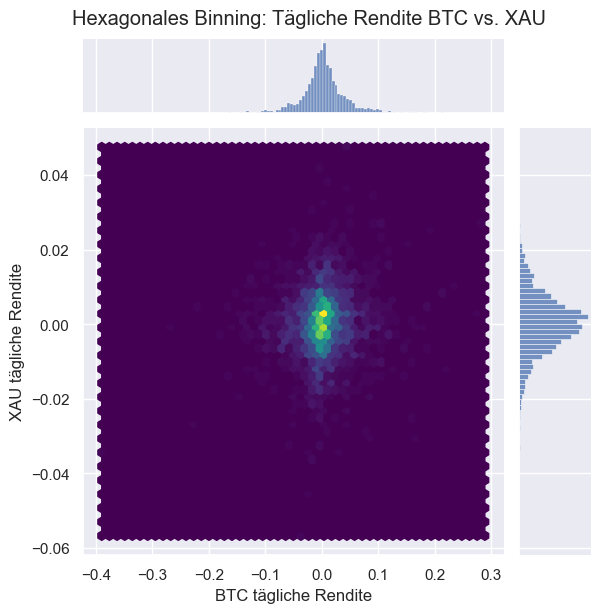

In [23]:
# Entferne NaN-Werte, die durch die Verschiebung entstehen
df_returns = df.dropna(subset=['return_btc', 'return_xau'])

# Hexagonales Binning
sns.jointplot(
    x='return_btc',
    y='return_xau',
    data=df_returns,
    kind='hex',
    gridsize=50,
    cmap='viridis'
)

plt.suptitle("Hexagonales Binning: Tägliche Rendite BTC vs. XAU", y=1.02)
plt.xlabel("BTC tägliche Rendite")
plt.ylabel("XAU tägliche Rendite")
plt.show()
